# Model Training / Entrenamiento de Modelos (ITG Stamina)

**ES:** Este notebook implementa la fase de modelado para estimar la dificultad de charts de stamina en ITG usando únicamente features estructurales que el parser de producción puede generar.

**EN:** This notebook implements the modeling phase to estimate ITG stamina chart difficulty using only structural features that the production parser can generate.

## Objetivo / Objective
- Entrenar y comparar modelos de regresión para predecir `difficulty`.
- Evaluar desempeño con MAE, R² y accuracies por tolerancia (±0.25, ±0.50, ±1.00).
- Interpretar el modelo mediante **Permutation Feature Importance**.
- Exportar un modelo final y un CSV con predicciones para análisis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

import joblib

## 1) Imports y dependencias

**ES:** Cargamos librerías de análisis, visualización y machine learning. Incluimos `Pipeline` + `StandardScaler` para mantener un flujo consistente entre modelos y evitar sesgos por escala.

**EN:** We load analysis, visualization, and machine learning libraries. We use `Pipeline` + `StandardScaler` to keep a consistent modeling flow and avoid scale-related bias.

In [ ]:
# EN: Load processed dataset for modeling.
# ES: Cargar el dataset procesado para el modelado.
df = pd.read_csv('../data/processed/stamina_dataset.csv')

# EN: Explicitly drop potentially collinear speed proxies not used in production feature set.
# ES: Eliminar explícitamente proxies de velocidad potencialmente colineales que no usamos en producción.
drop_columns = [col for col in ['average_nps', 'ebpm'] if col in df.columns]
df_model = df.drop(columns=drop_columns)

# EN: We only keep features that the production parser can derive directly from breakdown math.
# ES: Solo conservamos features que el parser de producción puede derivar directamente del breakdown.
if 'display_BPM' in df_model.columns:
    bpm_column = 'display_BPM'
elif 'display_bpm' in df_model.columns:
    bpm_column = 'display_bpm'
else:
    raise KeyError("Neither 'display_BPM' nor 'display_bpm' exists in the dataset columns.")

feature_columns = [
    'total_stream_length',
    'max_stream_length',
    'break_count',
    'stream_break_ratio',
    bpm_column,
]

X = df_model[feature_columns].copy()
X = X.rename(columns={bpm_column: 'display_BPM'})
y = df_model['difficulty'].copy()

# EN: We fill missing values with 0 to preserve all charts in the dataset.
# ES: Rellenamos nulos con 0 para conservar todos los charts en el dataset.
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (2281, 5)
X_test shape: (571, 5)


## 2) Carga de datos y preprocesamiento

**ES:**
- Cargamos el dataset procesado.
- Definimos `X` con features reproducibles por el parser (`total_stream_length`, `max_stream_length`, `break_count`, `stream_break_ratio`, `display_BPM`).
- Excluimos `average_nps` y `ebpm` para reducir colinealidad. 
- Aplicamos split 80/20 (`random_state=42`) y tratamiento de nulos.

**EN:**
- We load the processed dataset.
- We define `X` with parser-reproducible features only.
- We exclude `average_nps` and `ebpm` to reduce collinearity.
- We apply an 80/20 split (`random_state=42`) and handle missing values.

In [15]:
def accuracy_within_one(y_true: pd.Series, y_pred: np.ndarray) -> float:
    """
    EN: Return percentage of predictions within ±1 difficulty from true labels.
    ES: Devuelve el porcentaje de predicciones dentro de ±1 dificultad respecto a la etiqueta real.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true_array - y_pred_array) <= 1.0) * 100.0)


def tolerance_accuracy_summary(
    y_true: pd.Series,
    y_pred: np.ndarray,
    tolerances: tuple[float, ...] = (0.25, 0.50, 1.00),
) -> dict[str, float]:
    """
    EN: Compute cumulative accuracies for multiple absolute-error tolerances.
    ES: Calcula accuracies acumuladas para múltiples tolerancias de error absoluto.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    summary: dict[str, float] = {}
    for tolerance in tolerances:
        summary[f'Acc ±{tolerance:.2f} (%)'] = float(np.mean(abs_error <= tolerance) * 100.0)
    return summary


def absolute_error_bands(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """
    EN: Break down error percentages by absolute-error bands for interpretability.
    ES: Desglosa porcentajes por bandas de error absoluto para mayor interpretabilidad.
    """
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_error = np.abs(y_true_array - y_pred_array)

    return {
        'Err ≤0.25 (%)': float(np.mean(abs_error <= 0.25) * 100.0),
        'Err (0.25,0.50] (%)': float(np.mean((abs_error > 0.25) & (abs_error <= 0.50)) * 100.0),
        'Err (0.50,1.00] (%)': float(np.mean((abs_error > 0.50) & (abs_error <= 1.00)) * 100.0),
        'Err >1.00 (%)': float(np.mean(abs_error > 1.00) * 100.0),
    }


models = {
    'SVR (Banatt Baseline)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(C=1.0, epsilon=0.1)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42)),
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', HistGradientBoostingRegressor(random_state=42)),
    ]),
}

print('✅ Models and metric functions loaded successfully.')

✅ Models and metric functions loaded successfully.


## 3) Definición de métricas y modelos

**ES:** Definimos una métrica orientada al dominio (`accuracy within one`) y un desglose por tolerancias para distinguir predicciones exactas o casi exactas (ej. 15.00 vs 14.50 o 15.50).

**EN:** We define a domain-oriented metric (`accuracy within one`) and a tolerance breakdown to distinguish exact and near-exact predictions (e.g., 15.00 vs 14.50 or 15.50).

También instanciamos tres pipelines comparables:
- `SVR (Banatt Baseline)`
- `Random Forest`
- `Gradient Boosting`

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, pipeline in models.items():
    fold_mae = []
    fold_r2 = []
    fold_acc_025 = []
    fold_acc_050 = []
    fold_acc_100 = []

    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        pipeline.fit(X_fold_train, y_fold_train)
        y_fold_pred = pipeline.predict(X_fold_val)

        fold_mae.append(mean_absolute_error(y_fold_val, y_fold_pred))
        fold_r2.append(r2_score(y_fold_val, y_fold_pred))

        tol_summary = tolerance_accuracy_summary(y_fold_val, y_fold_pred)
        fold_acc_025.append(tol_summary['Acc ±0.25 (%)'])
        fold_acc_050.append(tol_summary['Acc ±0.50 (%)'])
        fold_acc_100.append(tol_summary['Acc ±1.00 (%)'])

    cv_rows.append({
        'Model': model_name,
        'Mean MAE': np.mean(fold_mae),
        'Mean R2': np.mean(fold_r2),
        'Mean Acc ±0.25 (%)': np.mean(fold_acc_025),
        'Mean Acc ±0.50 (%)': np.mean(fold_acc_050),
        'Mean Acc ±1.00 (%)': np.mean(fold_acc_100),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by='Mean MAE', ascending=True).reset_index(drop=True)

print('=== 5-Fold CV Summary (Training Split) ===')
for _, row in cv_results_df.iterrows():
    print(
        f"{row['Model']:<24} | MAE: {row['Mean MAE']:.4f} | R2: {row['Mean R2']:.4f} | "
        f"Acc±0.25: {row['Mean Acc ±0.25 (%)']:.2f}% | "
        f"Acc±0.50: {row['Mean Acc ±0.50 (%)']:.2f}% | "
        f"Acc±1.00: {row['Mean Acc ±1.00 (%)']:.2f}%"
    )

display(cv_results_df)

=== 5-Fold CV Summary (Training Split) ===
Random Forest            | MAE: 0.3636 | R2: 0.9920 | Acc±0.25: 50.64% | Acc±0.50: 74.31% | Acc±1.00: 95.00%
Gradient Boosting        | MAE: 0.3652 | R2: 0.9925 | Acc±0.25: 45.99% | Acc±0.50: 75.01% | Acc±1.00: 95.92%
SVR (Banatt Baseline)    | MAE: 0.5590 | R2: 0.9735 | Acc±0.25: 37.35% | Acc±0.50: 65.94% | Acc±1.00: 89.87%


,Model,Mean MAE,Mean R2,Mean Acc ±0.25 (%),Mean Acc ±0.50 (%),Mean Acc ±1.00 (%)
0,Random Forest,0.363610,0.992015,50.636877,74.310818,95.002015
1,Gradient Boosting,0.365214,0.992454,45.989481,75.010941,95.922588
2,SVR (Banatt Baseline),0.558971,0.973479,37.351914,65.936024,89.872836


## 4) Validación cruzada (5-Fold CV)

**ES:** Ejecutamos validación cruzada con `KFold(n_splits=5, shuffle=True, random_state=42)` para comparar modelos de forma robusta en múltiples particiones del training set.

**EN:** We run 5-fold cross-validation to compare models robustly across multiple training-set partitions.

Se reportan métricas promedio por modelo:
- MAE
- R²
- Accuracy por tolerancias (±0.25, ±0.50, ±1.00)

Best model selected from CV: Random Forest
Test MAE: 0.3311
Test R2: 0.9947
Test Acc ±0.25: 53.77%
Test Acc ±0.50: 74.61%
Test Acc ±1.00: 96.67%
Test Absolute Error Bands:
  - Err ≤0.25 (%): 53.77%
  - Err (0.25,0.50] (%): 20.84%
  - Err (0.50,1.00] (%): 22.07%
  - Err >1.00 (%): 3.33%


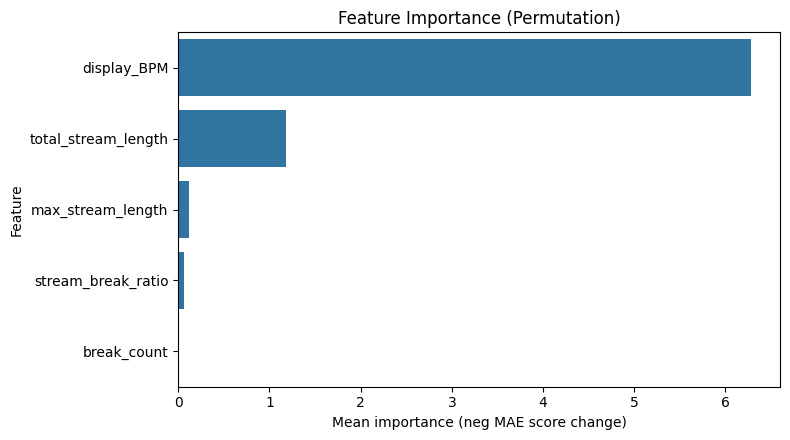

In [17]:
from sklearn.inspection import permutation_importance

best_model_name = cv_results_df.loc[0, 'Model']
best_model = models[best_model_name]

# EN: Retrain best model on full training data and evaluate once on hold-out test set.
# ES: Reentrenar el mejor modelo con todo training y evaluar una sola vez en test hold-out.
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
tol_test = tolerance_accuracy_summary(y_test, y_test_pred)
err_bands_test = absolute_error_bands(y_test, y_test_pred)

print(f'Best model selected from CV: {best_model_name}')
print(f'Test MAE: {test_mae:.4f}')
print(f'Test R2: {test_r2:.4f}')
print(f"Test Acc ±0.25: {tol_test['Acc ±0.25 (%)']:.2f}%")
print(f"Test Acc ±0.50: {tol_test['Acc ±0.50 (%)']:.2f}%")
print(f"Test Acc ±1.00: {tol_test['Acc ±1.00 (%)']:.2f}%")
print('Test Absolute Error Bands:')
for metric_name, metric_value in err_bands_test.items():
    print(f'  - {metric_name}: {metric_value:.2f}%')

perm = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring='neg_mean_absolute_error',
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=importance_df, x='importance', y='feature', orient='h')
plt.title('Feature Importance (Permutation)')
plt.xlabel('Mean importance (neg MAE score change)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5) Evaluación final en hold-out + importancia de variables

**ES:** Seleccionamos el mejor modelo según CV, lo reentrenamos en `X_train`/`y_train` y evaluamos en `X_test`/`y_test`. Luego calculamos **Permutation Feature Importance** para interpretar el aporte de cada feature.

**EN:** We select the best CV model, retrain on `X_train`/`y_train`, evaluate on `X_test`/`y_test`, and compute **Permutation Feature Importance** for interpretability.

In [18]:
from pathlib import Path

# EN: Train final model on the full dataset (X, y) for production export.
# ES: Entrenar el modelo final con todo el dataset (X, y) para exportación a producción.
final_model_full = models[best_model_name]
final_model_full.fit(X, y)

# EN: Ensure output directories exist.
# ES: Asegurar que existan los directorios de salida.
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

# EN: Export fitted final model.
# ES: Exportar el modelo final entrenado.
model_output_path = models_dir / 'stamina_model_v1.pkl'
joblib.dump(final_model_full, model_output_path)

# EN: Build prediction report with chart identifier + breakdown + true and predicted difficulty.
# ES: Construir reporte de predicción con identificador del chart + breakdown + dificultad real y predicha.
chart_col_candidates = ['source_file', 'chart_id', 'title', 'chart', 'chart_name', 'simfile_path', 'file_path', 'hash']
chart_col = next((col for col in chart_col_candidates if col in df.columns), None)
if chart_col is None:
    chart_series = pd.Series(df.index.astype(str), index=df.index)
else:
    chart_series = df[chart_col].astype(str)

breakdown_series = df['breakdown'].astype(str) if 'breakdown' in df.columns else pd.Series(['N/A'] * len(df), index=df.index)
true_difficulty = df['difficulty'].astype(int)
pred_difficulty = [f"{value:.2f}" for value in final_model_full.predict(X)]
bpm_series = X['display_BPM']

predictions_df = pd.DataFrame({
    'chart_to_classify': chart_series,
    'breakdown': breakdown_series,
    'BPM': bpm_series,
    'difficulty': true_difficulty,
    'predicted_difficulty': pred_difficulty,
})

predictions_output_path = processed_dir / 'stamina_predictions_full.csv'
predictions_df.to_csv(predictions_output_path, index=False)

print(f'✅ Final full-data model exported: {model_output_path.resolve()}')
print(f'✅ Prediction CSV exported: {predictions_output_path.resolve()}')
print(f'Chart identifier column used: {chart_col if chart_col is not None else "index"}')
print(f'Rows exported: {len(predictions_df)}')

✅ Final full-data model exported: /home/maru/Documents/Tesina/ITGStamina-rater-ml/ml-core/models/stamina_model_v1.pkl
✅ Prediction CSV exported: /home/maru/Documents/Tesina/ITGStamina-rater-ml/ml-core/data/processed/stamina_predictions_full.csv
Chart identifier column used: source_file
Rows exported: 2852


## 6) Exportación para producción y análisis

**ES:** Reentrenamos el modelo final con todo el dataset (`X`, `y`) y exportamos:
- Modelo serializado (`.pkl`) para inferencia.
- CSV de predicciones con chart, breakdown, BPM, dificultad real y dificultad predicha (`xx.xx`).

**EN:** We retrain on the full dataset and export both the serialized model and a prediction report CSV for downstream analysis.

## Conclusión / Conclusion

**ES:** Este notebook implementa la fase de modelado de forma reproducible y alineada al parser de producción. La comparación por CV y la evaluación hold-out confirman que los modelos de árbol superan al baseline histórico en error y estabilidad. Además, el reporte por tolerancias (±0.25, ±0.50, ±1.00) ofrece una lectura más útil para interpretar casos *low/high* dentro del mismo bloque de dificultad.

**EN:** This notebook delivers a reproducible modeling workflow aligned with production features. CV and hold-out results confirm that tree-based models outperform the historical baseline, while tolerance-based metrics provide finer insight for *low/high* difficulty interpretation within adjacent levels.